<a href="https://colab.research.google.com/github/dechl-98/ChavezDavid2534532021/blob/main/ClaveG/An%C3%A1lisis_de_Correlaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Caso 2 Correlación de datos ClaveG_correlacion
#Importando las librerías que se necesitarán para trabajar y presentar los datos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
#creamos variables para mandar a traer el dataset y mostrarlo preliminarmente
url = "https://raw.githubusercontent.com/dechl-98/ChavezDavid2534532021/refs/heads/main/ClaveG/clave_G_correlacion.csv"
df = pd.read_csv(url)
df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,G-C0001,36,1333,12,73.69,7.34,1,10,18.10,830.56
1,G-C0002,38,1318,11,107.75,8.31,1,10,21.55,998.80
2,G-C0003,40,1105,9,75.72,5.89,7,7,17.82,563.19
3,G-C0004,34,1349,6,60.43,7.41,1,4,24.88,353.01
4,G-C0005,52,1073,2,60.52,6.61,3,0,26.30,143.68


Las variables numericas del dataset son las siguientes: edad, ingresos_mensuales, frecuencia_compra, ticket_promedio, satisfaccion, reclamos, uso_app, tiempo_respuesta, consumo_total. Básicamente casi en su totalidad de datos son de tipos numericos, entre ellos de tipo entero y de tipo decimal

In [5]:
#Validación de los resultados
df.shape

(251, 10)

El dataset contiene 251 registros y 10 columnas. Este dato pretende analizar el consumo y tiempo por edades.

In [6]:
print("Primeras filas:")
print(df.head())

print("Informacion general:")
print(df.info())


Primeras filas:
  cliente_id  edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
0    G-C0001    36                1333                 12            73.69   
1    G-C0002    38                1318                 11           107.75   
2    G-C0003    40                1105                  9            75.72   
3    G-C0004    34                1349                  6            60.43   
4    G-C0005    52                1073                  2            60.52   

   satisfaccion  reclamos  uso_app  tiempo_respuesta  consumo_total  
0          7.34         1       10             18.10         830.56  
1          8.31         1       10             21.55         998.80  
2          5.89         7        7             17.82         563.19  
3          7.41         1        4             24.88         353.01  
4          6.61         3        0             26.30         143.68  
Informacion general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Da

Todas las variables contenidas son numericas a excepcion del id. Pero considerando los casos se pueden trabajar.

In [7]:
# 3. Revision de valores nulos
print("Valores nulos:")
print(df.isnull().sum())


Valores nulos:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64


hay un total de 3 valores nulos contenidos en; ticket_promedio, satisfaccion y tiempo_respuesta

In [8]:
# 4. Revision de duplicados
print("Registros duplicados:")
print(df.duplicated().sum())


Registros duplicados:
1


hay un solo registro duplicado

In [9]:
# 5. Estadistica descriptiva
print("Estadistica descriptiva:")
print(df.describe())


Estadistica descriptiva:
             edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
count  251.000000          251.000000         251.000000       250.000000   
mean    41.298805         1195.350598           8.250996        69.981560   
std     10.243552          243.400453           3.397168        13.865806   
min     18.000000          535.000000           2.000000        33.170000   
25%     34.000000         1051.000000           6.000000        60.527500   
50%     41.000000         1180.000000           8.000000        69.480000   
75%     48.000000         1348.000000          10.000000        79.057500   
max     68.000000         2116.000000          33.000000       111.840000   

       satisfaccion    reclamos     uso_app  tiempo_respuesta  consumo_total  
count    250.000000  251.000000  251.000000        250.000000     251.000000  
mean       7.564720    1.601594    5.968127         20.972880     565.327610  
std        1.408093    1.789033    2.070502 

In [10]:
# 6. Deteccion de valores atipicos
variables_numericas = [
    "edad",
    "ingresos_mensuales",
    "frecuencia_compra",
    "ticket_promedio",
    "satisfaccion",
    "reclamos",
    "uso_app",
    "tiempo_respuesta",
    "consumo_total"
]

print("Revision de valores atipicos:")
for columna in variables_numericas:
    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print("Variable:", columna)
    print("Media:", round(media, 2))
    print("Desviacion estandar:", round(desviacion, 2))
    print("Limite inferior:", round(limite_inferior, 2))
    print("Limite superior:", round(limite_superior, 2))
    print("Cantidad de valores atipicos:", len(atipicos))
    print("-" * 40)

Revision de valores atipicos:
Variable: edad
Media: 41.3
Desviacion estandar: 10.24
Limite inferior: 20.81
Limite superior: 61.79
Cantidad de valores atipicos: 10
----------------------------------------
Variable: ingresos_mensuales
Media: 1195.35
Desviacion estandar: 243.4
Limite inferior: 708.55
Limite superior: 1682.15
Cantidad de valores atipicos: 11
----------------------------------------
Variable: frecuencia_compra
Media: 8.25
Desviacion estandar: 3.4
Limite inferior: 1.46
Limite superior: 15.05
Cantidad de valores atipicos: 3
----------------------------------------
Variable: ticket_promedio
Media: 69.98
Desviacion estandar: 13.87
Limite inferior: 42.25
Limite superior: 97.71
Cantidad de valores atipicos: 17
----------------------------------------
Variable: satisfaccion
Media: 7.56
Desviacion estandar: 1.41
Limite inferior: 4.75
Limite superior: 10.38
Cantidad de valores atipicos: 11
----------------------------------------
Variable: reclamos
Media: 1.6
Desviacion estandar: 1.

In [13]:
# 7. Matriz de correlacion
matriz_correlacion = df.drop('cliente_id', axis=1).corr()

print("Matriz de correlacion:")
print(matriz_correlacion.round(3))

Matriz de correlacion:
                     edad  ingresos_mensuales  frecuencia_compra  \
edad                1.000               0.046             -0.002   
ingresos_mensuales  0.046               1.000              0.109   
frecuencia_compra  -0.002               0.109              1.000   
ticket_promedio     0.227               0.520              0.066   
satisfaccion       -0.095               0.006              0.241   
reclamos            0.132              -0.053             -0.151   
uso_app            -0.022              -0.051              0.521   
tiempo_respuesta    0.127              -0.020             -0.200   
consumo_total       0.070               0.312              0.877   

                    ticket_promedio  satisfaccion  reclamos  uso_app  \
edad                          0.227        -0.095     0.132   -0.022   
ingresos_mensuales            0.520         0.006    -0.053   -0.051   
frecuencia_compra             0.066         0.241    -0.151    0.521   
ticket_p

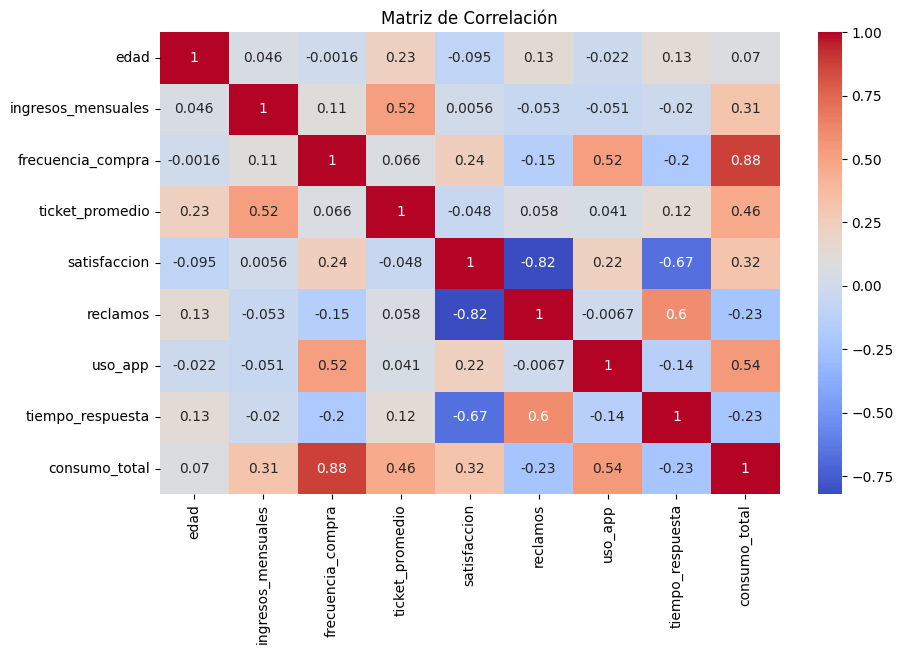

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()